In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap
import matplotlib.ticker as ticker

# Two-Mirror Concentrator

In [10]:
flat_source, target_type, inv, hl, f1, L, f2, da, a_max, w = np.loadtxt('datafin/input.csv', delimiter = ',')
mirror1a = np.loadtxt('datafin/mirror1a.csv', delimiter = ',')
mirror1b = np.loadtxt('datafin/mirror1b.csv', delimiter = ',')
mirror2a = np.loadtxt('datafin/mirror2a.csv', delimiter = ',')
mirror2b = np.loadtxt('datafin/mirror2b.csv', delimiter = ',')

In [11]:
from util import get_target_type_name

source_text = "flat" if flat_source else "cylindrical"
target_text = get_target_type_name(target_type)
inverted_text = "inverted" if inv else "not inverted"
print(f"{source_text} source -> {target_text} target, {inverted_text}")
print(f"half-length = {hl}, f1 = {f1}, L = {L}, f2 = {f2}, da = {da}, a_max = {a_max}, w = {w}")

flat source -> Flat target, not inverted
half-length = 0.001, f1 = 1.0, L = 30.0, f2 = 1.0, da = 1e-06, a_max = 75.0, w = 1.0


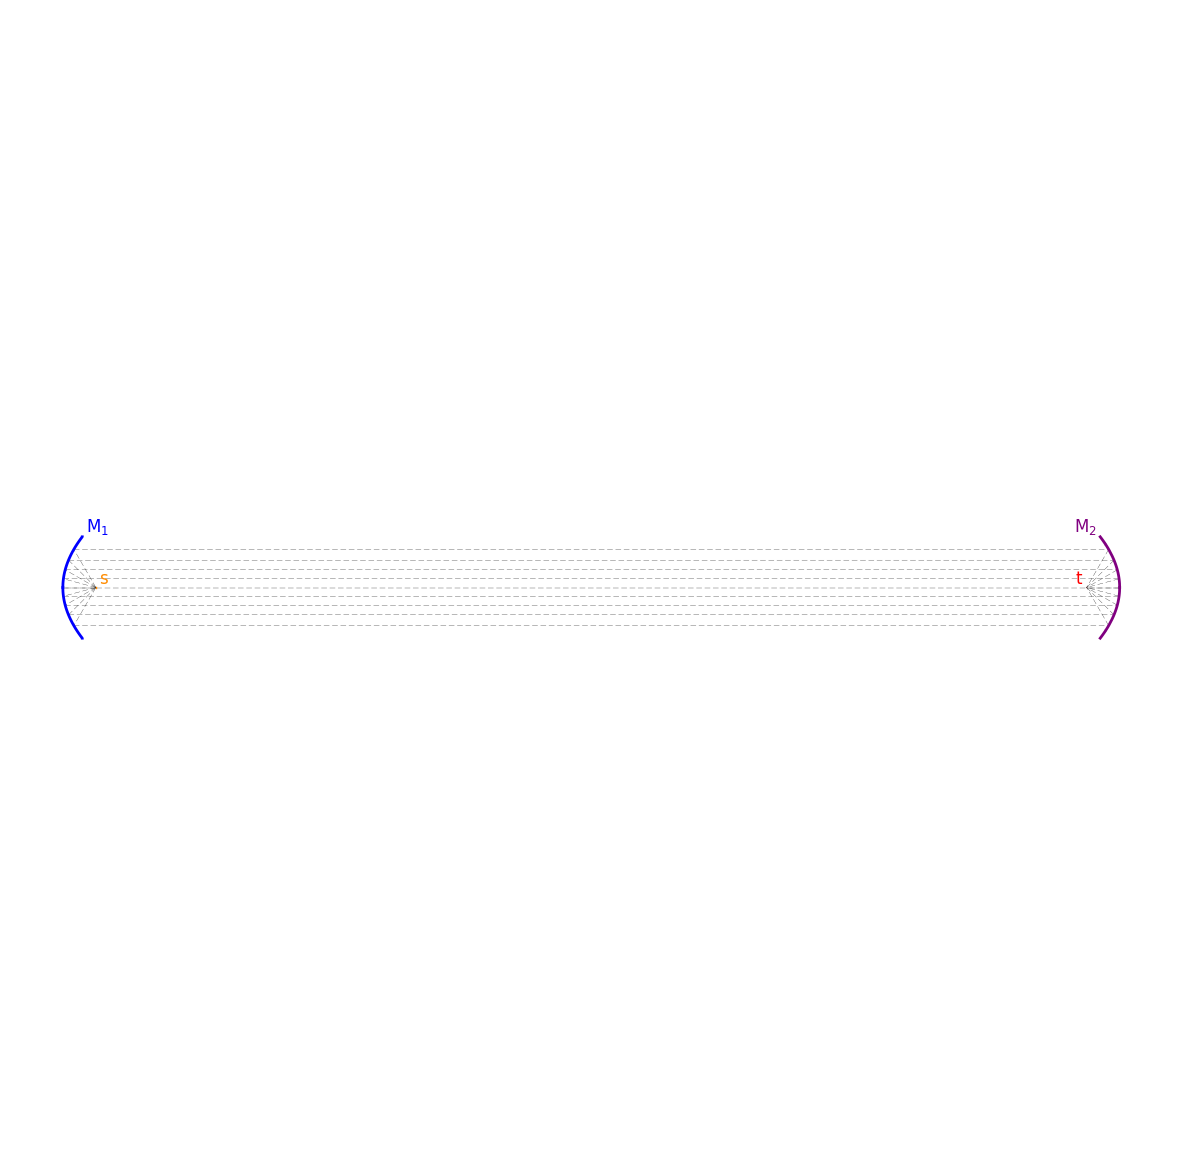

In [12]:
# setup
fig, ax = plt.subplots(1, figsize = (15, 15))
ax.spines['left'].set_position('zero')
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_position('zero')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['right'].set_position('zero')
ax.spines['right'].set_linewidth(0.5)
ax.spines['top'].set_position('zero')
ax.spines['top'].set_linewidth(0.5)
ax.set_xticks([])
ax.set_yticks([])

# rays
finalplotrays = np.loadtxt('datafin/finalplotrays.csv', delimiter = ',')
for row in finalplotrays: plt.plot([row[0], row[2]], [row[1], row[3]], linestyle = 'dashed', dashes = [20, 10], linewidth = 0.2, c = 'black')

# label adjustment
adj = 0.1

# ellipse
# plt.gca().add_patch(matplotlib.patches.Ellipse(xy = (-L / 2, 0), width = 2 * f1 + L, height = 2 * np.sqrt(f1 * (f1 + L)), edgecolor = 'palevioletred', facecolor = 'none', fill = False, lw = 4))
# ax.text(-L / 2 - adj, np.sqrt(f1 * (f1 + L)) + adj, ha = 'center', va = 'bottom', s = r"$\text{E}$", fontsize = 12, color = 'palevioletred')

# parabolas
# Y1 = np.linspace(-2 * f1, 2 * f1, 100)
# X1 = 1 / (4 * f1) * (Y1 ** 2) - L - f1
# ax.plot(X1, Y1, linewidth = 10, c = 'lightsteelblue', label = r"$\text{P}_1$")
# ax.text(X1[-1] + adj, Y1[1], ha = 'left', va = 'bottom', s = r"$\text{P}_1$", fontsize = 12, color = 'lightsteelblue')
# Y2 = np.linspace(-2 * f2, 2 * f2, 100)
# X2 = -1 / (4 * f2) * (Y2 ** 2) + f2
# ax.plot(X2, Y2, linewidth = 10, c = 'thistle', label = r"$\text{P}_2$")
# ax.text(X2[-1] - adj, Y2[1], ha = 'right', va = 'bottom', s = r"$\text{P}_2$", fontsize = 12, color = 'thistle')

# mirrors
ax.plot(mirror1a[:, 0], mirror1a[:, 1], linewidth = 2, c = 'blue', label = r"$\text{M}_1$")
ax.plot(mirror1b[:, 0], mirror1b[:, 1], linewidth = 2, c = 'blue')
ax.text(mirror1a[-1, 0] + adj, mirror1a[-1, 1], ha = 'left', va = 'bottom', s = r"$\text{M}_1$", fontsize = 12, color = 'blue')
ax.plot(mirror2a[:, 0], mirror2a[:, 1], linewidth = 2, c = 'purple', label = r"$\text{M}_2$")
ax.plot(mirror2b[:, 0], mirror2b[:, 1], linewidth = 2, c = 'purple')
ax.text(mirror2a[-1, 0] - adj, mirror2a[-1, 1], ha = 'right', va = 'bottom', s = r"$\text{M}_2$", fontsize = 12, color = 'purple')

# source
if flat_source: plt.plot([-L - f1 / 100, -L - f1 / 100], [-hl, hl], linewidth = 1, color = 'darkorange', label = 'source')
else: plt.gca().add_patch(plt.Circle((-L, 0), hl, color = 'darkorange', label = 'source'))
# plt.annotate(r"$\text{s}$", xy = (-L, 0), xytext = ((mirror1a[0, 0] + L) * 1.25 - L, mirror1a[-1, 1] / 2), color = 'darkorange',
#              arrowprops = dict(arrowstyle = '-', linestyle = 'dashed', linewidth = 0.5, color = 'darkorange', shrinkA = 5, shrinkB = 10),
#              horizontalalignment = 'center')
ax.text(-L + adj, 0, ha = 'left', va = 'bottom', s = r"$\text{s}$", fontsize = 12, color = 'darkorange')

# target
if flat_target:
	if not flat_source: hl *= np.pi
	plt.plot([0 + f2 / 100, 0 + f2 / 100], [-hl, hl], linewidth = 1, color = 'red', label = 'target')
else:
	if flat_source: hl / np.pi
	plt.gca().add_patch(plt.Circle((0, 0), hl, color = 'red', label = 'target'))
# plt.annotate(r"$\text{t}$", xy = (0, 0), xytext = (mirror2a[0, 0] * 1.25, mirror2a[-1, 1] / 2), color = 'red',
#              arrowprops = dict(arrowstyle = '-', linestyle = 'dashed', linewidth = 0.5, color = 'red', shrinkA = 5, shrinkB = 10),
#              horizontalalignment = 'center')
ax.text(0 - adj, 0, ha = 'right', va = 'bottom', s = r"$\text{t}$", fontsize = 12, color = 'red')


plt.axis('equal')
plt.axis('off')
# plt.legend(bbox_to_anchor = (1, 1), loc = 'upper left')
plt.show()

---

# Extreme Rays

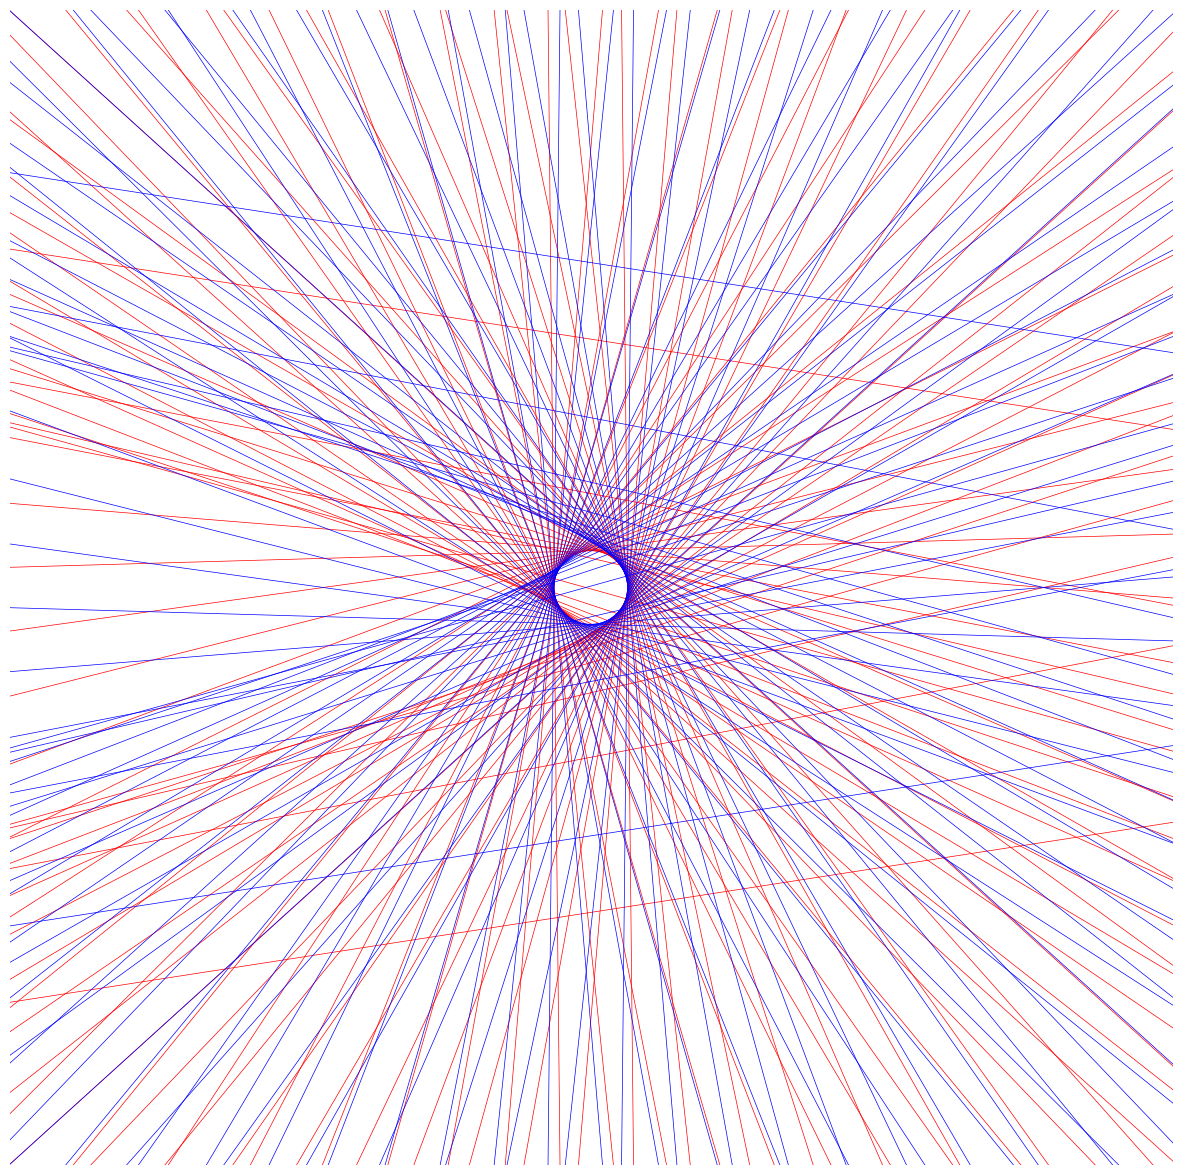

In [975]:
fig, ax = plt.subplots(1, figsize = (15, 15))
extreme1 = np.loadtxt('datafin/extrdiff1.csv', delimiter = ',')
extreme2 = np.loadtxt('datafin/extrdiff2.csv', delimiter = ',')
for row in extreme1: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.5, c = 'red')
for row in extreme2: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.5, c = 'blue')
if flat_source and flat_target: plt.plot([0, 0], [-hl, hl], linewidth = 4, color = 'black', label = 'target')
elif not flat_source and flat_target: plt.plot([0, 0], [-hl, hl], linewidth = 4, color = 'black', label = 'target')
plt.axis('equal')
zoom = hl * 5
plt.axis([-zoom, zoom, -zoom, zoom])
plt.axis('off')
plt.show()

---

# Phase Space

In [990]:
# flat target
# fig, ax = plt.subplots(1, figsize = (10, 10))
# ax.tick_params(axis = 'x', direction = 'in', bottom = True, top = False, labelsize = 8)
# ax.tick_params(axis = 'y', direction = 'in', left = True, right = False, labelsize = 8)
# ax.spines['left'].set_position(('data', -1))
# ax.spines['left'].set_bounds((-1, 1))
# ax.spines['left'].set_linewidth(0.5)
# ax.spines['bottom'].set_position(('data', -1))
# ax.spines['bottom'].set_bounds((-1, 1))
# ax.spines['bottom'].set_linewidth(0.5)
# ax.spines['right'].set_position(('data', 1))
# ax.spines['right'].set_bounds((-1, 1))
# ax.spines['right'].set_linewidth(0.5)
# ax.spines['top'].set_position(('data', 1))
# ax.spines['top'].set_bounds((-1, 1))
# ax.spines['top'].set_linewidth(0.5)
# phase_target = np.loadtxt('datafin/phasetarget.csv', delimiter = ',')
# max = np.max(phase_target[:, 1])
# ax.scatter(phase_target[:, 0], phase_target[:, 1] / max, s = 0.1)
# ax.set_xlabel(r"$\sin\theta$")
# ax.set_ylabel(r"$y$")
# plt.axis('equal')
# plt.show()

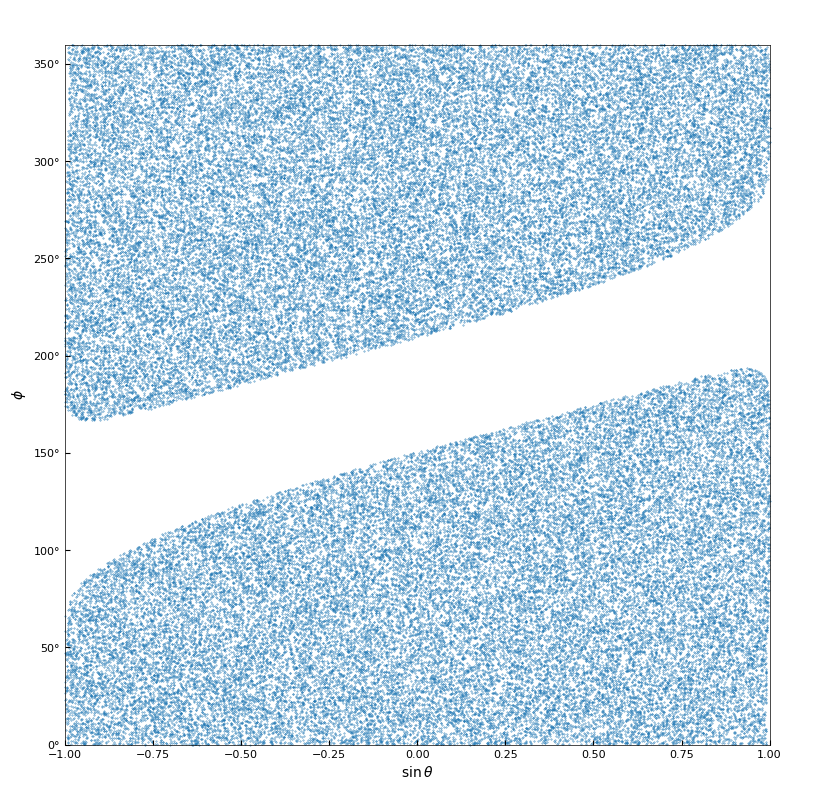

In [977]:
# cylindrical target
fig, ax = plt.subplots(1, figsize = (10, 10))
ax.tick_params(axis = 'x', direction = 'in', bottom = True, top = False, labelsize = 8)
ax.tick_params(axis = 'y', direction = 'in', left = True, right = False, labelsize = 8)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}°"))
ax.spines['left'].set_position(('data', -1))
ax.spines['left'].set_bounds((0, 360))
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_bounds((-1, 1))
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['right'].set_position(('data', 1))
ax.spines['right'].set_bounds((0, 360))
ax.spines['right'].set_linewidth(0.5)
ax.spines['top'].set_position(('data', 360))
ax.spines['top'].set_bounds((-1, 1))
ax.spines['top'].set_linewidth(0.5)
phase_target = np.loadtxt('datafin/phasetarget.csv', delimiter = ',')
ax.scatter(phase_target[:, 0], phase_target[:, 1], s = 0.1)
ax.set_xlabel(r"$\sin\theta$")
ax.set_ylabel(r"$\phi$")
plt.show()

# Magnification

In [989]:
# source
# fig, ax = plt.subplots(1, figsize = (5, 10))
# ax.tick_params(axis = 'x', direction = 'in', bottom = True, top = False, labelsize = 6)
# ax.tick_params(axis = 'y', direction = 'in', left = True, right = False, labelsize = 6)
# ax.spines['left'].set_position(('data', -1))
# ax.spines['left'].set_bounds((-w, w))
# ax.spines['left'].set_linewidth(0.5)
# ax.spines['bottom'].set_position(('data', -w))
# ax.spines['bottom'].set_bounds((-1, 1))
# ax.spines['bottom'].set_linewidth(0.5)
# ax.spines['right'].set_position(('data', 1))
# ax.spines['right'].set_bounds((-w, w))
# ax.spines['right'].set_linewidth(0.5)
# ax.spines['top'].set_position(('data', w))
# ax.spines['top'].set_bounds((-1, 1))
# ax.spines['top'].set_linewidth(0.5)
# ax.scatter(phase_target[:, 2], phase_target[:, 3] / hl, s = 0.01)
# ax.set_xlabel(r"$\sin\theta$")
# ax.set_ylabel(r"$y$")
# plt.axis('equal')
# plt.show()

In [988]:
# target
# fig, ax = plt.subplots(1, figsize = (5, 10))
# ax.tick_params(axis = 'x', direction = 'in', bottom = True, top = False, labelsize = 6)
# ax.tick_params(axis = 'y', direction = 'in', left = True, right = False, labelsize = 6)
# ax.spines['left'].set_position(('data', -1))
# ax.spines['left'].set_bounds((-w, w))
# ax.spines['left'].set_linewidth(0.5)
# ax.spines['bottom'].set_position(('data', -w))
# ax.spines['bottom'].set_bounds((-1, 1))
# ax.spines['bottom'].set_linewidth(0.5)
# ax.spines['right'].set_position(('data', 1))
# ax.spines['right'].set_bounds((-w, w))
# ax.spines['right'].set_linewidth(0.5)
# ax.spines['top'].set_position(('data', w))
# ax.spines['top'].set_bounds((-1, 1))
# ax.spines['top'].set_linewidth(0.5)
# ax.scatter(phase_target[:, 0], phase_target[:, 1] / hl, s = 0.01)
# ax.set_xlabel(r"$\sin\theta$")
# ax.set_ylabel(r"$y$")
# plt.axis('equal')
# plt.show()

---

# Hit Data

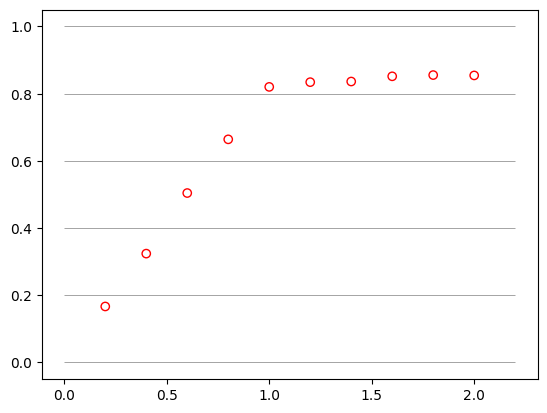

In [980]:
hit_data = np.loadtxt('datafin/hitdata.csv', delimiter = ',')
plt.scatter(hit_data[:, 0], hit_data[:, 1], facecolors = 'none', edgecolors = (1, 0, 0))
plt.hlines(y = [0, 0.2, 0.4, 0.6, 0.8, 1], xmin = 0, xmax = hit_data[-1, 0] + hit_data[0, 0], linewidth = 0.5, color = 'grey')
plt.show()

---

# Archive

In [981]:
# target_size = 1
# if flat_source and flat_target: target_size = radius
# elif flat_source and not flat_target: target_size = radius / np.pi
# elif not flat_source and flat_target: target_size = radius * np.pi
# elif not flat_source and not flat_target: target_size = radius
# zoom = 1.5 * target_size
# scale = 0.1
# plt.axis([-zoom, zoom, -zoom, zoom])
# plt.axis([-zoom * scale, zoom * scale, target_size - zoom * scale, target_size + zoom * scale])
# plt.axis([-zoom * scale * target_size, zoom * scale * target_size, target_size - zoom * scale * target_size, target_size + zoom * scale * target_size])

In [982]:
# plt.scatter(phase_target[:, 0], phase_target[:, 1], s = 3, c = phase_target[:, 3], cmap = 'coolwarm')
# plt.xlabel("sine of angle between incident ray and target normal", c = 'grey')
# if flat_target: plt.ylabel("y-coordinate of target", c = 'grey')
# else: plt.ylabel("angle of position on cylindrical target wrt/ +x axis", c = 'grey')
# if flat_source: plt.colorbar(label = "y-coordinate of sampled diffuse ray")
# else: plt.colorbar(label = "angle of position on cylindrical source of sampled diffuse ray wrt/ -x axis")
# plt.title("phase space hit plot of target")
# plt.grid(True, c = 'r')
# plt.show()

In [983]:
# phase_mirror1 = np.loadtxt('datafin/phasemirror1.csv', delimiter = ',')
# phase_mirror2 = np.loadtxt('datafin/phasemirror2.csv', delimiter = ',')

In [984]:
# plt.scatter(phase_mirror1[:, 0], phase_mirror1[:, 1], s = 0.1, c = phase_mirror1[:, 2], cmap = 'coolwarm')
# plt.xlabel("sine of angle between incident ray and mirror 1 normal", c = 'grey')
# plt.ylabel("length from mirror 1 centre to hit", c = 'grey')
# plt.colorbar(label = "angle between sampled diffuse ray and source normal")
# plt.title("phase space hit plot of mirror 1")
# plt.grid(True, c = 'r')
# plt.show()

In [985]:
# plt.scatter(phase_mirror1[:, 0], phase_mirror1[:, 1], s = 0.1, c = phase_mirror1[:, 3], cmap = 'coolwarm')
# plt.xlabel("sine of angle between incident ray and mirror 1 normal", c = 'grey')
# plt.ylabel("length from mirror 1 centre to hit", c = 'grey')
# if flat_source: plt.colorbar(label = "y-coordinate of sampled diffuse ray")
# else: plt.colorbar(label = "angle of position on cylindrical source of sampled diffuse ray wrt/ -x axis")
# plt.title("phase space hit plot of mirror 1")
# plt.grid(True, c = 'r')
# plt.show()

In [986]:
# plt.scatter(phase_mirror2[:, 0], phase_mirror2[:, 1], s = 0.1, c = phase_mirror2[:, 2], cmap = 'coolwarm')
# plt.xlabel("sine of angle between incident ray and mirror 2 normal", c = 'grey')
# plt.ylabel("length from mirror 2 centre to hit", c = 'grey')
# plt.colorbar(label = "angle between sampled diffuse ray and source normal")
# plt.title("phase space hit plot of mirror 2")
# plt.grid(True, c = 'r')
# plt.show()

In [987]:
# plt.scatter(phase_mirror2[:, 0], phase_mirror2[:, 1], s = 0.1, c = phase_mirror2[:, 3], cmap = 'coolwarm')
# plt.xlabel("sine of angle between incident ray and mirror 2 normal", c = 'grey')
# plt.ylabel("length from mirror 2 centre to hit", c = 'grey')
# if flat_source: plt.colorbar(label = "y-coordinate of sampled diffuse ray")
# else: plt.colorbar(label = "angle of position on cylindrical source of sampled diffuse ray wrt/ -x axis")
# plt.title("phase space hit plot of mirror 2")
# plt.grid(True, c = 'r')
# plt.show()